<a href="https://colab.research.google.com/github/adriano-klein/clearbank-analise/blob/main/analise_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Requisitos opcionais

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
endereco = "/content/drive/MyDrive/Estudo Python - Pós em IA/Desafio/transacoes.csv"

In [44]:
def processar_dados_pandas(endereco):
    df = pd.read_csv(endereco)
    df = df.dropna(subset=['id', 'cliente_id'])
    df['id'] = df['id'].astype(str)
    df['valor'] = pd.to_numeric(df['valor'], errors='coerce')
    df = df.dropna(subset=['valor'])
    df = df[df['valor'] > 0]
    df = df[df['tipo'].isin(['credito', 'debito'])]
    df['data'] = pd.to_datetime(df['data'], errors='coerce')
    df = df.dropna(subset=['data'])
    df['mes'] = df['data'].dt.strftime('%Y-%m')

    return df

In [45]:
def gerar_metricas_pandas(df):
    df['valor_credito'] = df['valor'].where(df['tipo'] == 'credito', 0.0)
    df['valor_debito'] = df['valor'].where(df['tipo'] == 'debito', 0.0)

    resumo = df.groupby('mes').agg(
        quantidade = ('id', 'count'),
        total_credito = ('valor_credito', 'sum'),
        total_debito = ('valor_debito', 'sum'),
        media = ('valor', 'mean'),
        maior_valor = ('valor', 'max'),
        menor_valor = ('valor', 'min')
    )
    resumo['saldo'] = resumo['total_credito'] - resumo['total_debito']

    return resumo

In [46]:
dados = processar_dados_pandas(endereco)

In [47]:
dados_para_grafico = gerar_metricas_pandas(dados)

In [48]:
dados_para_grafico.head()

,quantidade,total_credito,total_debito,media,maior_valor,menor_valor,saldo
mes,,,,,,,
2026-01,5,16000.0,345.5,3269.10,12500.0,45.0,15654.5
2026-02,5,15500.0,659.9,3231.98,15000.0,89.9,14840.1
2026-03,5,3950.0,1449.9,1079.98,3500.0,99.9,2500.1


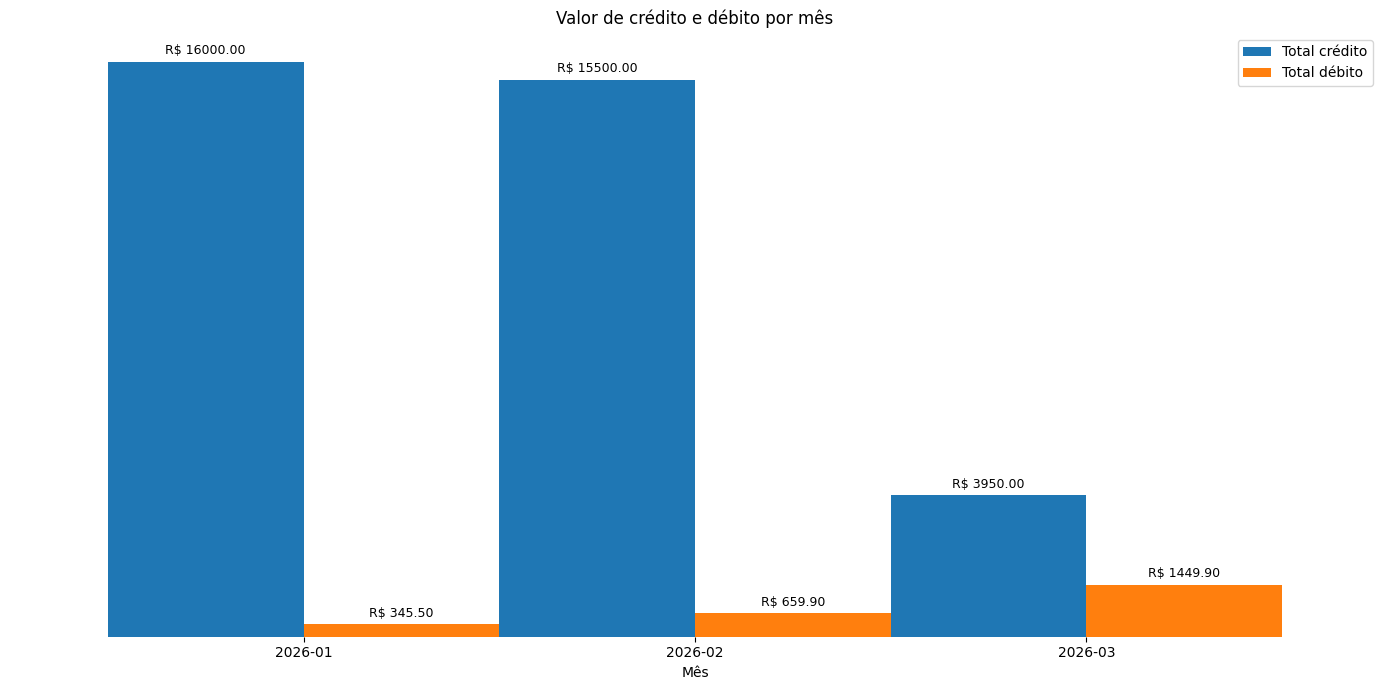

In [49]:
dados_grafico = dados_para_grafico.groupby(['mes'])[['total_credito','total_debito']].sum()
ax = dados_grafico.plot(kind='bar', width=1, figsize=(14,7))

for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.2f", padding=3, fontsize=9)

plt.legend(['Total crédito','Total débito'])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.yticks([], [])
plt.xlabel('Mês')
plt.xticks(rotation=0)
plt.title('Valor de crédito e débito por mês')
plt.tight_layout()
plt.savefig('grafico.png', dpi=72, bbox_inches='tight')
plt.show()

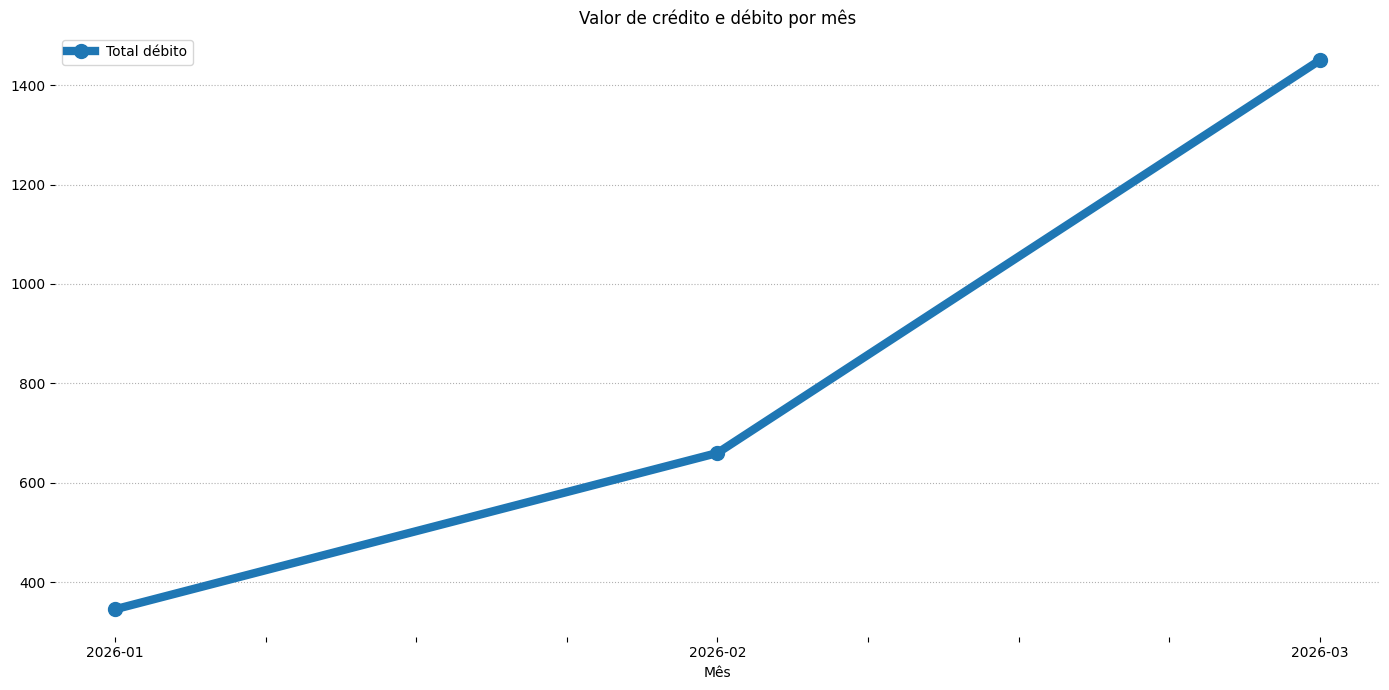

In [50]:
ax = dados_grafico['total_debito'].plot(kind='line', figsize=(14,7), linewidth='6', marker='o', markersize='10')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.legend(['Total débito'])
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle=':')
plt.xlabel('Mês')
plt.xticks(rotation=0)
plt.title('Valor de crédito e débito por mês')
plt.tight_layout()
plt.tight_layout()

plt.savefig('grafico_linhas.png', dpi=72, bbox_inches='tight')
plt.show()

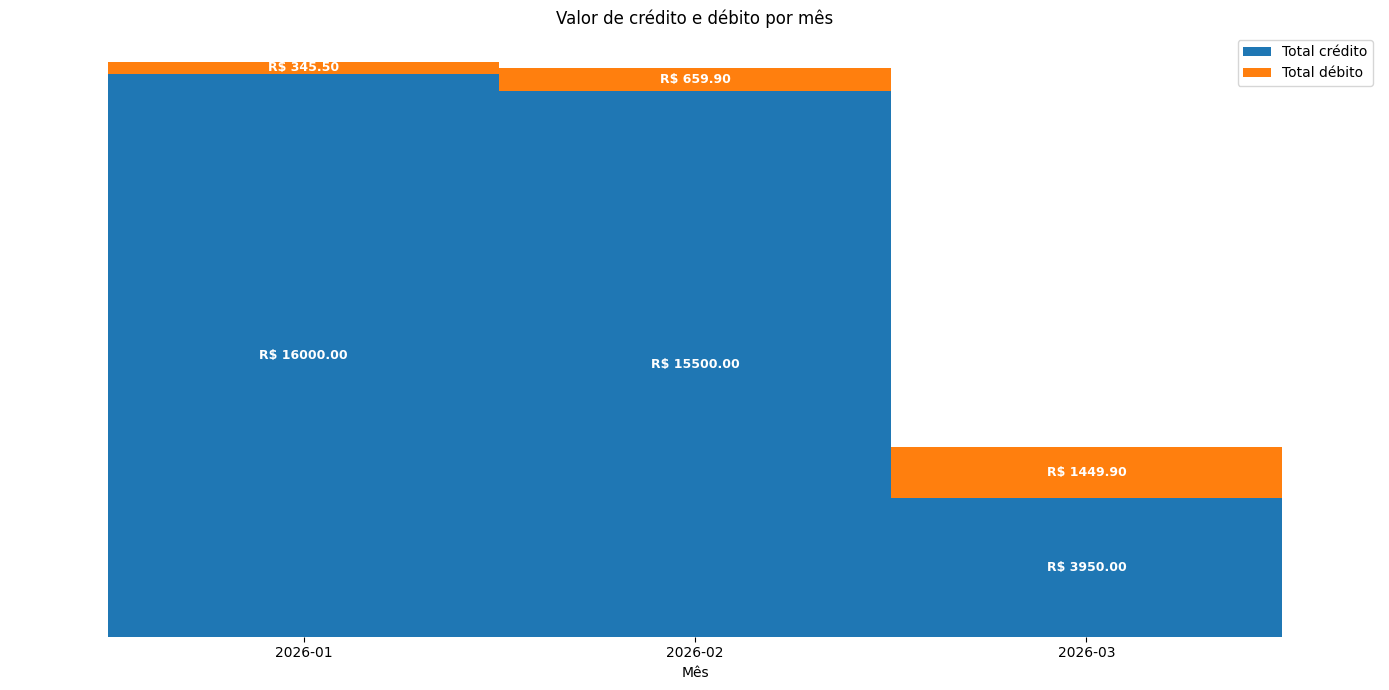

In [51]:
dados_grafico = dados_para_grafico.groupby(['mes'])[['total_credito','total_debito']].sum()
ax = dados_grafico.plot(kind='bar', width=1, figsize=(14,7), stacked=True)

for container in ax.containers:
    ax.bar_label(container, fmt="R$ %.2f", label_type='center', fontsize=9, fontweight='bold', color='white')

plt.legend(['Total crédito','Total débito'])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.yticks([], [])
plt.xlabel('Mês')
plt.xticks(rotation=0)
plt.title('Valor de crédito e débito por mês')
plt.tight_layout()

plt.savefig('grafico_barras_empilhadas.png', dpi=72, bbox_inches='tight')
plt.show()